Day 1: Initial Data Exploration

**Project:** Do the decision boundaries of tree-based ML models align with theoretical blazar
physics when separating BL Lacs from FSRQs, and can those boundaries confidently classify
Fermi-LAT blazar candidates of uncertain type (BCUs)?

**Dataset:** Fermi-LAT 4LAC-DR3, high-latitude sample (`table-4LAC-DR3-h.fits`)

### Goals for today
1. Acquire the catalog and load the FITS file into a `pandas` DataFrame.
2. Audit the schema — what columns exist, what types, what's missing.
3. Audit the `CLASS` label column carefully (there is a subtlety here — see §4).
4. Split into a **known** set (`bll` / `fsrq`) for training and an **unknown** set (`bcu`) held out for Day 5.
5. Select features, justify every drop, and check for leakage.
6. Write down a **pre-registered physical prediction** before any model is trained.
7. Save clean, reproducible CSVs for Day 2.

**Explicitly not today:** no model, no train/test split, no accuracy numbers. Day 2 is the baseline.

## 1. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from astropy.table import Table
from astropy.io import fits

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 60)

# Resolve the repo root whether we're running locally (notebooks/) or on Colab.
if Path.cwd().name == "notebooks":
    ROOT = Path.cwd().parent
else:
    ROOT = Path.cwd()

RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"
RAW.mkdir(parents=True, exist_ok=True)
PROCESSED.mkdir(parents=True, exist_ok=True)

CATALOG_URL = "https://fermi.gsfc.nasa.gov/ssc/data/access/lat/4LACDR3/table-4LAC-DR3-h.fits"
CATALOG_PATH = RAW / "table-4LAC-DR3-h.fits"

print("repo root:", ROOT)

repo root: /Users/saanikakulkarni/Documents/source-code/blazar_aiss


## 2. Acquire the catalog

The high-latitude file (`-h`) restricts to |b| > 10°, avoiding the Galactic plane where source
confusion and diffuse emission degrade the spectral fits. That's the standard cut for
population studies and it's why we use it rather than the full-sky table.

This cell is idempotent — it only downloads if the file isn't already there.

In [2]:
if not CATALOG_PATH.exists():
    import urllib.request
    print(f"downloading {CATALOG_URL} ...")
    urllib.request.urlretrieve(CATALOG_URL, CATALOG_PATH)

print(f"{CATALOG_PATH.name}: {CATALOG_PATH.stat().st_size / 1e6:.2f} MB")

table-4LAC-DR3-h.fits: 0.91 MB


## 3. Load the FITS file and audit the schema

In [3]:
with fits.open(CATALOG_PATH) as hdul:
    hdul.info()

Filename: /Users/saanikakulkarni/Documents/source-code/blazar_aiss/data/raw/table-4LAC-DR3-h.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  4LAC_DR3 AGNs    1 BinTableHDU    181   3407R x 41C   [18A, I, E, E, E, E, E, E, E, E, E, 18A, E, E, E, E, E, E, E, I, 5A, 30A, E, E, 20A, D, D, D, 20A, E, 6A, E, E, E, E, E, E, E, E, E, E]   


The science data lives in HDU 1 (`4LAC_DR3 AGNs`), a binary table. HDU 0 is the near-empty
primary header that every FITS file carries by convention.

In [4]:
table = Table.read(CATALOG_PATH)          # astropy picks the first table HDU automatically
df_raw = table.to_pandas()

print(f"rows: {len(df_raw)}   columns: {len(df_raw.columns)}")

rows: 3407   columns: 41


In [5]:
# FITS stores strings as fixed-width bytes; pandas surfaces them as b'...' objects.
# Decode every byte column to real str so that string ops work downstream.
def decode_bytes(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    for col in out.columns:
        if out[col].dtype == object and out[col].map(lambda v: isinstance(v, bytes)).any():
            out[col] = out[col].str.decode("utf-8", errors="ignore")
    return out


df_raw = decode_bytes(df_raw)
df_raw.dtypes.to_frame("dtype").T

,Source_Name,DataRelease,RAJ2000,DEJ2000,GLON,GLAT,Signif_Avg,Flux1000,Unc_Flux1000,Energy_Flux100,Unc_Energy_Flux100,SpectrumType,PL_Index,Unc_PL_Index,Pivot_Energy,LP_Index,Unc_LP_Index,LP_beta,Unc_LP_beta,Flags,CLASS,ASSOC1,ASSOC_PROB_BAY,ASSOC_PROB_LR,Counterpart_Catalog,RA_Counterpart,DEC_Counterpart,Unc_Counterpart,VLBI_Counterpart,Redshift,SED_class,HE_EPeak,Unc_HE_EPeak,HE_nuFnuPeak,Unc_HE_nuFnuPeak,nu_syn,nuFnu_syn,Variability_Index,Frac_Variability,Unc_Frac_Variability,Highest_energy
dtype,object,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,object,float32,float32,float32,float32,float32,float32,float32,int16,object,object,float32,float32,object,float64,float64,float64,object,float32,object,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32


In [6]:
# Full column inventory — worth reading once so nothing surprises us later.
pd.DataFrame({
    "column": df_raw.columns,
    "dtype": [str(df_raw[c].dtype) for c in df_raw.columns],
    "n_missing": [int(df_raw[c].isna().sum()) for c in df_raw.columns],
})

,column,dtype,n_missing
0,Source_Name,object,0
1,DataRelease,int16,0
2,RAJ2000,float32,0
3,DEJ2000,float32,0
4,GLON,float32,0
5,GLAT,float32,0
6,Signif_Avg,float32,0
7,Flux1000,float32,0
8,Unc_Flux1000,float32,0
9,Energy_Flux100,float32,0


## 4. Audit the label column

This is the step most likely to silently corrupt the whole project, so we look at the raw
values with `repr()` — that exposes trailing whitespace and case that `value_counts()` alone
would hide.

In [7]:
df_raw["CLASS"].apply(repr).value_counts().to_frame("count")

,count
CLASS,
'bll',1357
'bcu',1208
'fsrq',715
'FSRQ',40
'rdg',36
'BLL',22
'agn',6
'RDG',6
'css',5


### Two things to notice

**(a) Case is meaningful in 4FGL/4LAC.** `FSRQ` and `fsrq` are *not* a data-entry mistake.
The Fermi convention is:

- **UPPERCASE** = *identified* — the association is confirmed by a physical measurement, e.g.
  correlated variability or a resolved counterpart.
- **lowercase** = *associated* — a probable counterpart found by positional/statistical
  likelihood, but not independently confirmed.

Both are real BL Lacs / FSRQs as far as their physics goes, so for a classification task we
fold them together. But this is a deliberate scientific choice, not a cleaning accident —
worth one sentence in the writeup, because folding case is exactly the kind of thing a
reviewer will ask about.

**(b) Non-blazar AGN are present.** `rdg` (radio galaxies), `nlsy1`, `css`, `ssrq`, `sey`.
These are AGN but not blazars — their jets aren't pointed at us. They get dropped: the
research question is specifically about the BL Lac / FSRQ dichotomy.

In [8]:
df = df_raw.copy()
df["CLASS_clean"] = df["CLASS"].str.strip().str.lower()

counts = df["CLASS_clean"].value_counts().to_frame("count")
counts["pct"] = (100 * counts["count"] / len(df)).round(1)
counts

,count,pct
CLASS_clean,,
bll,1379,40.5
bcu,1208,35.5
fsrq,755,22.2
rdg,42,1.2
nlsy1,8,0.2
agn,7,0.2
css,5,0.1
ssrq,2,0.1
sey,1,0.0


## 5. Split into known (trainable) and unknown (target) populations

In [9]:
KNOWN_CLASSES = ["bll", "fsrq"]
UNKNOWN_CLASS = "bcu"

known = df[df["CLASS_clean"].isin(KNOWN_CLASSES)].copy()
unknown = df[df["CLASS_clean"] == UNKNOWN_CLASS].copy()

n_bll = int((known["CLASS_clean"] == "bll").sum())
n_fsrq = int((known["CLASS_clean"] == "fsrq").sum())

print(f"known (trainable):  {len(known):5d}   bll={n_bll}  fsrq={n_fsrq}")
print(f"unknown (BCU):      {len(unknown):5d}")
print(f"dropped (other AGN):{len(df) - len(known) - len(unknown):5d}")
print(f"\\nclass imbalance: {n_bll / n_fsrq:.2f} : 1  (bll : fsrq)")

known (trainable):   2134   bll=1379  fsrq=755
unknown (BCU):       1208
dropped (other AGN):   65
\nclass imbalance: 1.83 : 1  (bll : fsrq)


**On the imbalance:** roughly 1.8:1. That is mild. It's enough that raw accuracy is a poor
metric — a model predicting "BL Lac" for everything scores ~65% — which is exactly why we
report ROC-AUC and per-class precision/recall instead.

It is *not* severe enough to warrant SMOTE. Synthetic minority oversampling would interpolate
new points in (spectral index, variability) space, and those interpolated points don't
correspond to any physical object. `class_weight="balanced"` achieves the same rebalancing in
one keyword with no fabricated data, so that's the route we take on Day 2.

## 6. Feature selection

Four physical features, chosen because each maps onto a distinct piece of blazar physics:

| Feature | Physics |
|---|---|
| `PL_Index` | Power-law photon index Γ. The spectral slope. Higher Γ = softer = more FSRQ-like. |
| `Variability_Index` | How strongly the flux varied across the mission. FSRQ jets are more turbulent. |
| `Flux1000` | Integral photon flux, 1–100 GeV. Apparent brightness. |
| `Pivot_Energy` | Energy at which the flux uncertainty is minimised; correlates with spectral shape. |

### What we drop, and why

- **`Source_Name`, `ASSOC1`, `Counterpart_Catalog`, `VLBI_Counterpart`** — identifiers. A tree
  can memorise naming conventions that correlate with discovery epoch, which correlates with
  class. Textbook leakage.
- **`RAJ2000`, `DEJ2000`, `GLON`, `GLAT`** — sky position. Blazar physics doesn't depend on
  where the object sits on our sky; letting the model use coordinates invites it to learn
  survey selection artefacts instead of physics.
- **`Unc_*` columns** — measurement uncertainties. These scale with brightness and exposure,
  so they smuggle in observational rather than intrinsic information.
- **`Redshift`, `nu_syn`, `SED_class`, `HE_EPeak`** — the interesting judgement call. These are
  strong discriminators, but they are *derived from optical/broadband data* — precisely the
  observations a BCU lacks. Training on them would produce a model that cannot be applied to
  the BCUs at all. Excluding them keeps the study honest and purely gamma-ray.
- **`LP_Index`, `LP_beta`** — log-parabola fit parameters, only populated for sources fit with
  that spectral model. Using them would introduce structured missingness tied to source
  brightness.

In [11]:
FEATURES = ["PL_Index", "Variability_Index", "Flux1000", "Pivot_Energy"]
LABEL = "CLASS_clean"

# Sanity check: are these actually complete, or will we be silently dropping rows?
missing = pd.DataFrame({
    "known_missing": known[FEATURES].isna().sum(),
    "unknown_missing": unknown[FEATURES].isna().sum(),
})
missing["known_pct"] = (100 * missing["known_missing"] / len(known)).round(2)
missing

,known_missing,unknown_missing,known_pct
PL_Index,0,0,0.0
Variability_Index,0,0,0.0
Flux1000,0,0,0.0
Pivot_Energy,0,0,0.0


All four features are fully populated for both populations — no rows are lost. Good news, and
worth stating explicitly, because "drop NaNs" is a step that can quietly delete a biased
subset of your sample without you noticing.

In [12]:
known[FEATURES].describe().T

,count,mean,std,min,25%,50%,75%,max
PL_Index,2134.0,2.185264e+00,2.952611e-01,1.418864e+00,1.951355e+00,2.163937e+00,2.404253e+00,3.075706e+00
Variability_Index,2134.0,3.477775e+02,2.821194e+03,1.600064e+00,1.414150e+01,2.444417e+01,7.999573e+01,8.434076e+04
Flux1000,2134.0,9.845376e-10,3.037007e-09,2.096403e-11,1.730883e-10,3.248313e-10,7.339613e-10,7.406493e-08
Pivot_Energy,2134.0,2.452493e+03,2.613131e+03,2.623532e+02,9.050412e+02,1.678523e+03,3.052400e+03,3.457144e+04


### One derived feature

`Variability_Index` spans about five orders of magnitude, so we add a `log10` version.

A caveat worth being precise about: **Random Forests are invariant to monotonic transforms.**
Splitting on `x > 80` and `log10(x) > 1.9` partition the data identically, so this log will not
change model performance at all. We take it because it makes scatter plots and SHAP dependence
plots readable — an interpretability convenience, not a modelling requirement.

In [13]:
for frame in (known, unknown):
    frame["log10_Variability_Index"] = np.log10(frame["Variability_Index"])
    frame["log10_Flux1000"] = np.log10(frame["Flux1000"])

print("Variability_Index range: "
      f"{known['Variability_Index'].min():.1f} to {known['Variability_Index'].max():.1f}"
      f"  ({np.log10(known['Variability_Index'].max() / known['Variability_Index'].min()):.1f} orders of magnitude)")

Variability_Index range: 1.6 to 84340.8  (4.7 orders of magnitude)


## 7. Pre-registered prediction

The research question asks whether the model's learned boundaries *agree with* blazar physics.
To keep that falsifiable rather than a story told after the fact, we write the prediction down
now, before any model exists.

> **Prediction.** `PL_Index` will be the single most important feature. FSRQs will concentrate
> at Γ ≳ 2.3 and BL Lacs at Γ ≲ 2.1, and the model's primary decision boundary will fall near
> Γ ≈ 2.2 — consistent with the FSRQ/BL Lac separation reported in the 4LAC catalog paper.
> Secondary importance goes to variability, with FSRQs the more variable population.

On Day 4, SHAP either confirms this or it doesn't. Both outcomes are publishable results;
only the second one is interesting to explain.

The cell below establishes the *data-level* class separation. This is legitimate exploratory
statistics on the training population — not a peek at model performance.

In [14]:
summary = known.groupby(LABEL)[["PL_Index", "log10_Variability_Index"]].agg(["mean", "median", "std"])
summary.round(3)

PL_Index               log10_Variability_Index              
                mean median    std                    mean median    std
CLASS_clean                                                             
bll            2.030  2.024  0.211                   1.377  1.267  0.470
fsrq           2.469  2.449  0.202                   2.013  1.885  0.774

In [15]:
gamma_bll = known.loc[known[LABEL] == "bll", "PL_Index"]
gamma_fsrq = known.loc[known[LABEL] == "fsrq", "PL_Index"]

# Standardised separation between the two class means, in pooled standard deviations.
pooled_sd = np.sqrt((gamma_bll.var(ddof=1) + gamma_fsrq.var(ddof=1)) / 2)
cohens_d = (gamma_fsrq.mean() - gamma_bll.mean()) / pooled_sd

print(f"BL Lac  <Gamma> = {gamma_bll.mean():.3f} +/- {gamma_bll.std():.3f}")
print(f"FSRQ    <Gamma> = {gamma_fsrq.mean():.3f} +/- {gamma_fsrq.std():.3f}")
print(f"separation      = {cohens_d:.2f} pooled sigma")
print(f"\\nBCU     <Gamma> = {unknown['PL_Index'].mean():.3f} "
      f"(sits between the two known populations, as expected for a mixture)")

BL Lac  <Gamma> = 2.030 +/- 0.211
FSRQ    <Gamma> = 2.469 +/- 0.202
separation      = 2.12 pooled sigma
\nBCU     <Gamma> = 2.258 (sits between the two known populations, as expected for a mixture)


## 8. First look at the feature distributions

Two quick histograms — enough to confirm the separation is visible by eye. Full EDA and the
Γ vs variability scatter belong to Day 2.

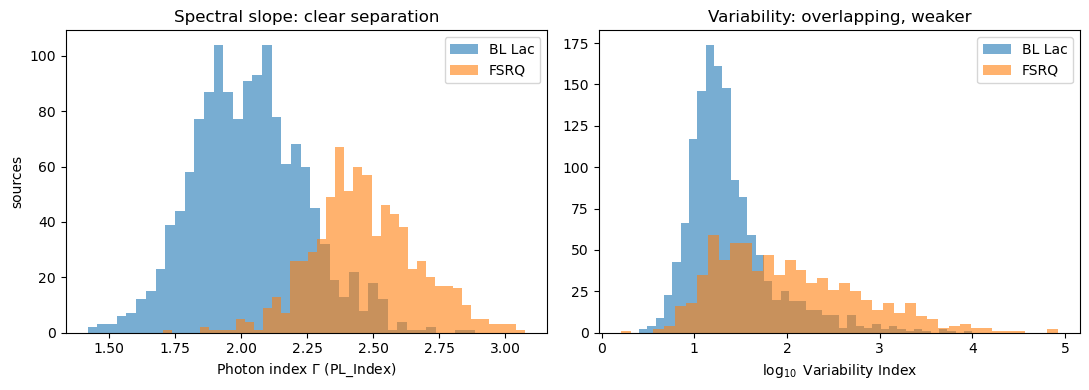

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for cls, label in [("bll", "BL Lac"), ("fsrq", "FSRQ")]:
    sel = known[LABEL] == cls
    axes[0].hist(known.loc[sel, "PL_Index"], bins=40, alpha=0.6, label=label)
    axes[1].hist(known.loc[sel, "log10_Variability_Index"], bins=40, alpha=0.6, label=label)

axes[0].set_xlabel(r"Photon index $\Gamma$ (PL_Index)")
axes[0].set_ylabel("sources")
axes[0].set_title("Spectral slope: clear separation")

axes[1].set_xlabel(r"$\log_{10}$ Variability Index")
axes[1].set_title("Variability: overlapping, weaker")

for ax in axes:
    ax.legend()

fig.tight_layout()
plt.show()

Spectral index separates the classes cleanly; variability overlaps heavily. This is the first
hint that the model may lean almost entirely on Γ — which makes the *confidence calibration*
work on Day 3 and the BCU application on Day 5 the genuinely interesting parts of the project,
rather than the headline accuracy number.

## 9. Save processed data for Day 2

In [17]:
KEEP = ["Source_Name", LABEL] + FEATURES + ["log10_Variability_Index", "log10_Flux1000"]

known_out = known[KEEP].reset_index(drop=True)
unknown_out = unknown[KEEP].reset_index(drop=True)

known_path = PROCESSED / "known_blazars.csv"
unknown_path = PROCESSED / "bcu_candidates.csv"

known_out.to_csv(known_path, index=False)
unknown_out.to_csv(unknown_path, index=False)

print(f"wrote {known_path.relative_to(ROOT)}   {known_out.shape}")
print(f"wrote {unknown_path.relative_to(ROOT)}   {unknown_out.shape}")
known_out.head()

wrote data/processed/known_blazars.csv   (2134, 8)
wrote data/processed/bcu_candidates.csv   (1208, 8)


,Source_Name,CLASS_clean,PL_Index,Variability_Index,Flux1000,Pivot_Energy,log10_Variability_Index,log10_Flux1000
0,4FGL J0001.2-0747,bll,2.116692,46.780693,7.471219e-10,1721.603882,1.670067,-9.126609
1,4FGL J0001.4-0010,bll,1.939160,9.272764,1.082246e-10,4307.082520,0.967209,-9.965674
2,4FGL J0001.5+2113,fsrq,2.654060,1910.935791,1.347354e-09,329.773743,3.281246,-8.870519
3,4FGL J0002.1-6728,bll,1.847773,12.530725,2.588808e-10,3140.743408,1.097976,-9.586900
4,4FGL J0003.2+2207,bll,2.116417,12.451856,9.928427e-11,4582.178223,1.095234,-10.003119


## Day 1 summary

- **3,407** high-latitude 4LAC-DR3 AGN loaded from FITS.
- **2,134 labelled blazars** for training: 1,379 BL Lacs, 755 FSRQs (1.83:1 — mild imbalance,
  handled with `class_weight`, not SMOTE).
- **1,208 BCUs** held out untouched as the Day 5 target population.
- **4 gamma-ray features**, all fully populated, all free of identifier/positional leakage,
  and all measurable for a BCU.
- Case-folding of the 4LAC identified/associated convention documented as a deliberate choice.
- Prediction pre-registered: Γ dominant, boundary near 2.2.

**Day 2:** the Γ vs variability scatter, then a baseline Random Forest with
`class_weight="balanced"`, a confusion matrix, and a ROC curve — end to end, however rough.
That milestone is the one that guarantees the capstone exists.